# Set environment

In [32]:
### Basic
import numpy  as np
import scipy  as sc
import pandas as pd
import glob, os, re
import pickle, sys

from scipy import interp

### import flowImg
py_path = "/local_data/notebooks/clintko/GitRepo/Proj_Flow2Image"
sys.path.insert(0, py_path)
from flowImg import *

### sklearn
from sklearn.metrics import roc_curve, auc, accuracy_score

### plot
import matplotlib.pyplot as plt
plt.style.use("seaborn-whitegrid")

### global const
SEED    = 123
DAT_DIR = "/data/clintko/flow_EQAPOL_normal/pipe01"

# Load data

In [2]:
!ls /data/clintko/flow_EQAPOL_normal/pipe01

model_vgg16_lr5e6_bs10_noBNorm.h5		 wrap01_data.P
model_vgg16_lr5e6_bs10_noBNorm_history.P	 wrap02_scaled_k0.P
model_vgg16_lr5e6_bs10_noBNorm.yaml		 wrap03_subs_1e4_N100.P
model_vgg16_lre5_bs10_noBNorm.h5		 wrap03_subs_1e4_N10.P
model_vgg16_noBNorm_lr5e6_bs10_SEB.h5		 wrap03_subs_1e4_N50.P
model_vgg16_noBNorm_lr5e6_bs10_SEB_history.P	 wrap04_tsne_1e4_N10.P
model_vgg16_noBNorm_lr5e6_bs10_SEB.yaml		 wrap04_tsne_1e4_N50.P
model_vgg16_noBNorm_lr5e6_bs50_class3.h5	 wrap05_img_1e4_N50_var01.P
model_vgg16_noBNorm_lr5e6_bs50_class3_history.P  wrap05_img_1e4_N50_var10.P
model_vgg16_noBNorm_lr5e6_bs50_class3.yaml	 wrap05_img_1e4_var01.P
model_vgg16_noBNorm_lr5e6_bs50_SEB.h5		 wrap05_img_1e4_var02.P
model_vgg16_noBNorm_lr5e6_bs50_SEB_history.P	 wrap05_img_1e4_var05.P
model_vgg16_noBNorm_lr5e6_bs50_SEB.yaml		 wrap05_img_1e4_var10.P


In [3]:
###
fname = "wrap05_img_1e4_var01.P"
fpath = os.path.join(DAT_DIR, fname)
file  = open(fpath, "rb")
wrap_tsne_v01 = pickle.load(file)
file.close()


In [ ]:
###
fname = "wrap05_img_1e4_var02.P"
fpath = os.path.join(DAT_DIR, fname)
file  = open(fpath, "rb")
wrap_tsne_v02 = pickle.load(file)
file.close()

In [3]:
###
fname = "wrap05_img_1e4_var05.P"
fpath = os.path.join(DAT_DIR, fname)
file  = open(fpath, "rb")
wrap_tsne_v05 = pickle.load(file)
file.close()

In [4]:
###
fname = "wrap05_img_1e4_N50_var01.P"
fpath = os.path.join(DAT_DIR, fname)
file  = open(fpath, "rb")
wrap_tsne_n50_v01 = pickle.load(file)
file.close()

# Perform PCA on the image and apply logistic regression

In [4]:
print(wrap_tsne_v01)

Label: Counter({0: 110, 1: 110, 2: 110})
    0: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109]
    1: [110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127
 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145
 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162 163
 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180 181
 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198 199
 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216 217
 218 219]
    2: [220 221 222 223 224 225 226 227 228 229 2

In [6]:
dat_img = wrap_tsne_v01
dat_img_train, dat_img_test = leave_one_out_split(dat_img, 0, 11, 10)

print(dat_img_train)
print(dat_img_test)

Label: Counter({0: 100, 1: 100, 2: 100})
    0: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95
 96 97 98 99]
    1: [100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117
 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135
 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153
 154 155 156 157 158 159 160 161 162 163 164 165 166 167 168 169 170 171
 172 173 174 175 176 177 178 179 180 181 182 183 184 185 186 187 188 189
 190 191 192 193 194 195 196 197 198 199]
    2: [200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216 217
 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234 235
 236 237 238 239 240 241 242 243 244 245 246 247 248 249 250 251 252 253
 254 2

# Perform PCA on the image and apply logistic regression (N10)

In [ ]:
dat_img = wrap_tsne_v01
dat_img_train, dat_img_test = leave_one_out_split(dat_img, 0, 11, 10)

In [7]:
pca_logreg = Classify_PCA_LogReg(dat_img_train, pca_explained_ratio = 0.9)
%time pca_logreg = pca_logreg.fit(dat_img_train)

PCA explained ratio:    0.9
PCA num components:     218
Original    data shape: (300, 229376)
PCA reduced data shape: (300, 218)
Log.Reg. Accuracy:      1.0
CPU times: user 2min 25s, sys: 1min 40s, total: 4min 5s
Wall time: 15 s


In [9]:
res = pca_logreg.predict(dat_img_test)
print(res['acc'])
print(res['predicted_class'].shape)
print(res['predicted_prob'].shape)
print(res['predicted_score'].shape)

0.6
(30,)
(30, 3)
(30, 3)


In [10]:
print(res['predicted_class'])
print(dat_img_test.label)

[2 0 1 0 0 0 0 0 1 0 1 1 0 1 0 1 0 1 0 1 0 2 1 2 2 2 2 1 1 1]
[0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2]


In [12]:
FPR, TPR, ROC_AUC = dict(), dict(), dict()

In [14]:
### get label: test data and predicted
res = pca_logreg.predict(dat_img_test)
y_prob = res['predicted_prob']
y_test = dat_img_test.label
y_test = to_categorical(y_test)

print(y_prob.shape)
print(y_test.shape)

(30, 3)
(30, 3)


In [ ]:
x_img  = x_tst   
    y_lab  = y_tst
    y_prob = model.predict_proba(x_img)

    ### Compute micro-average ROC curve and ROC area
    fpr, tpr, _ = roc_curve(y_lab.ravel(), y_prob.ravel())
    roc_auc = auc(fpr, tpr)
    FPR.append(fpr)
    TPR.append(tpr)
    ROC_AUC.append(roc_auc)

In [ ]:
fpr, tpr, _ = roc_curve(y_lab.ravel(), y_prob.ravel())
    roc_auc = auc(fpr, tpr)
    FPR.append(fpr)
    TPR.append(tpr)
    ROC_AUC.append(roc_auc)

STEP: ROC curve
+++++++++++++++++++++++++++++++++++


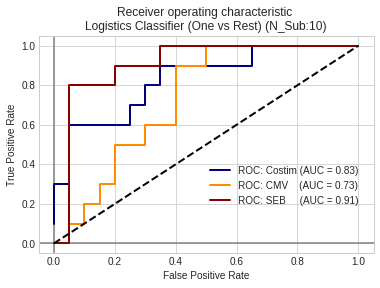

In [15]:
# Compute ROC curve and ROC area for each class
print("STEP: ROC curve")
print("+++++++++++++++++++++++++++++++++++")

### init
fpr, tpr, roc_auc = dict(), dict(), dict()
n_classes = len(dat_img.unique_label())

### get label: test data and predicted
res = pca_logreg.predict(dat_img_test)
y_prob = res['predicted_prob']
y_test = dat_img_test.label
y_test = to_categorical(y_test)

### calculate fpr and tpr
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

#######################################################

### set plot
plt.figure()
lw = 2

### since there is only two classes, below are the same
plt.plot(fpr[0], tpr[0], color='navy',       lw=lw, label='ROC: Costim (AUC = %0.2f)' % roc_auc[0])
plt.plot(fpr[1], tpr[1], color='darkorange', lw=lw, label='ROC: CMV    (AUC = %0.2f)' % roc_auc[1])
plt.plot(fpr[2], tpr[2], color='darkred',    lw=lw, label='ROC: SEB     (AUC = %0.2f)' % roc_auc[2])

### visualize ROC curve
plt.plot([0, 1], [0, 1], color='black', lw=lw, linestyle='--')
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.vlines(0, -0.05, 1.05, color = "Gray")
plt.hlines(0, -0.05, 1.05, color = "Gray")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic \nLogistics Classifier (One vs Rest) (N_Sub:10)')
plt.legend(loc=(0.5, 0.2)) #plt.legend(loc="lower right")

plt.show()

# Perform PCA on the image and apply logistic regression (N10)

In [30]:
dat_img   = wrap_tsne_v01
n_classes = len(dat_img.unique_label())
FPR, TPR, ROC_AUC = dict(), dict(), dict()

for idx in range(11):
    print("kfold: k =", idx)
    dat_img_train, dat_img_test = leave_one_out_split(dat_img, idx, 11, 10)
    pca_logreg = Classify_PCA_LogReg(dat_img_train, pca_explained_ratio = 0.9)  
    pca_logreg = pca_logreg.fit(dat_img_train, verbose = 0)
    
    print("    Predict")
    res = pca_logreg.predict(dat_img_test)
    y_prob = res['predicted_prob']
    y_test = dat_img_test.label
    y_test = to_categorical(y_test)
    
    ### calculate fpr and tpr
    print("    ROC")
    fpr, tpr, roc_auc = dict(), dict(), dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        
    FPR[idx]     = fpr
    TPR[idx]     = tpr
    ROC_AUC[idx] = roc_auc

kfold: k = 0
    Predict
    ROC
kfold: k = 1
    Predict
    ROC
kfold: k = 2
    Predict
    ROC
kfold: k = 3
    Predict
    ROC
kfold: k = 4
    Predict
    ROC
kfold: k = 5
    Predict
    ROC
kfold: k = 6
    Predict
    ROC
kfold: k = 7
    Predict
    ROC
kfold: k = 8
    Predict
    ROC
kfold: k = 9
    Predict
    ROC
kfold: k = 10
    Predict
    ROC


# Visualization

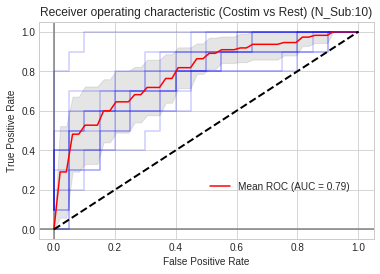

In [64]:
###
idx_class = 0
lw = 2
rocs = list()

###
for k in FPR.keys():
    ###
    base_fpr = np.linspace(0, 1, 50)
    
    ###
    fpr     = FPR[k][idx_class]
    tpr     = TPR[k][idx_class]
    roc_auc = ROC_AUC[k][idx_class]
    plt.plot(fpr, tpr, 'b', alpha=0.2)  
    
    ###
    roc = interp(base_fpr, fpr, tpr)
    roc[0] = 0.0
    rocs.append(roc)

###
rocs    = np.array(rocs)
rocs_mu = rocs.mean(axis=0)
rocs_sd = rocs.std(axis=0)    
rocs_upper = np.minimum(rocs_mu + rocs_sd, 1)
rocs_lower = rocs_mu - rocs_sd
roc_auc    = auc(base_fpr, rocs_mu)

###
plt.plot(base_fpr, rocs_mu, 'r', alpha=1, label='Mean ROC (AUC = %0.2f)' % roc_auc)
plt.fill_between(base_fpr, rocs_lower, rocs_upper, color='grey', alpha=0.2)

### visualize ROC curve
plt.plot([0, 1], [0, 1], color='black', lw=lw, linestyle='--')
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.vlines(0, -0.05, 1.05, color = "Gray")
plt.hlines(0, -0.05, 1.05, color = "Gray")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic \nCostim vs Rest (N_subsample:10)')
plt.legend(loc=(0.5, 0.2)) 
pass

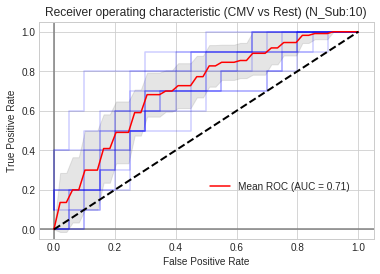

In [65]:
idx_class = 1
lw = 2
rocs = list()

for k in FPR.keys():
    ###
    base_fpr = np.linspace(0, 1, 50)
    
    ###
    fpr     = FPR[k][idx_class]
    tpr     = TPR[k][idx_class]
    roc_auc = ROC_AUC[k][idx_class]
    plt.plot(fpr, tpr, 'b', alpha=0.2)  
    
    ###
    roc = interp(base_fpr, fpr, tpr)
    roc[0] = 0.0
    rocs.append(roc)

###
rocs    = np.array(rocs)
rocs_mu = rocs.mean(axis=0)
rocs_sd = rocs.std(axis=0)    
rocs_upper = np.minimum(rocs_mu + rocs_sd, 1)
rocs_lower = rocs_mu - rocs_sd
roc_auc    = auc(base_fpr, rocs_mu)

###
plt.plot(base_fpr, rocs_mu, 'r', alpha=1, label='Mean ROC (AUC = %0.2f)' % roc_auc)
plt.fill_between(base_fpr, rocs_lower, rocs_upper, color='grey', alpha=0.2)

### visualize ROC curve
plt.plot([0, 1], [0, 1], color='black', lw=lw, linestyle='--')
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.vlines(0, -0.05, 1.05, color = "Gray")
plt.hlines(0, -0.05, 1.05, color = "Gray")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic \nCMV vs Rest (N_subsample:10)')
plt.legend(loc=(0.5, 0.2)) 
pass

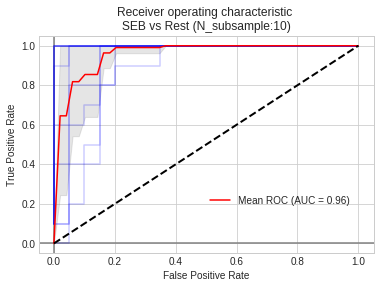

In [67]:
idx_class = 2
lw = 2
rocs = list()

for k in FPR.keys():
    ###
    base_fpr = np.linspace(0, 1, 50)
    
    ###
    fpr     = FPR[k][idx_class]
    tpr     = TPR[k][idx_class]
    roc_auc = ROC_AUC[k][idx_class]
    plt.plot(fpr, tpr, 'b', alpha=0.2)  
    
    ###
    roc = interp(base_fpr, fpr, tpr)
    roc[0] = 0.0
    rocs.append(roc)

###
rocs    = np.array(rocs)
rocs_mu = rocs.mean(axis=0)
rocs_sd = rocs.std(axis=0)    
rocs_upper = np.minimum(rocs_mu + rocs_sd, 1)
rocs_lower = rocs_mu - rocs_sd
roc_auc    = auc(base_fpr, rocs_mu)

###
plt.plot(base_fpr, rocs_mu, 'r', alpha=1, label='Mean ROC (AUC = %0.2f)' % roc_auc)
plt.fill_between(base_fpr, rocs_lower, rocs_upper, color='grey', alpha=0.2)

### visualize ROC curve
plt.plot([0, 1], [0, 1], color='black', lw=lw, linestyle='--')
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.vlines(0, -0.05, 1.05, color = "Gray")
plt.hlines(0, -0.05, 1.05, color = "Gray")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic \nSEB vs Rest (N_subsample:10)')
plt.legend(loc=(0.5, 0.2)) 
pass